In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
df_raw = pd.read_csv('online_retail_II.csv', encoding='latin1')
df_raw.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
## Data Audit and inspection

#1. Data Structure and type.
print('===INFO===')
print(df_raw.info())

#2 Inspecting Missing values.
print('\n===Missing Values===')
print(df_raw.isnull().sum())

#3 Numeric distribution audit (Inspecting quantity and price)
print('\n===Numeric Summary===')
print(df_raw[['Quantity', 'Price']].describe())

## Observations-
# Customer_id contains substantial null values(Unregestered guest transactions).
#Quantity includes negative values which often represent with c to refer invoice code at the
#beginning for return or cancelations.
#Price also includes negative values or zero corresponding to
#administrative adjustments, damaged inventory, or bad debt write-offs.

===INFO===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None

===Missing Values===
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

===Numeric Summary===
           Quantity         Price
count  1.067371e+06  1.067371e+06
mean   9.938898e+00  4.649388e+00
std    1.727058e+02  1.235531e+02

In [ ]:
#Cleaning and filtering the data:-

# Capture raw row count.
raw_row_count = len(df_raw)
print('raw row count:', raw_row_count)

#filter out negative and zero quantity and prices.
clean_filter = (df_raw['Quantity'] > 0) & (df_raw['Price'] > 0)

#Excluding missing customer ids.
clean_df = df_raw[clean_filter & df_raw['Customer ID'].notnull()].copy()

#Converting customer id data type to integer.
clean_df['Customer ID'] = clean_df['Customer ID'].astype('int')

clean_rows = len(clean_df)
print(f"Purged {raw_row_count - clean_rows:,} un-trackable or dirty records.")
print(f"Remaining Clean Records: {clean_rows:,}")

raw row count: 1067371
Purged 261,822 un-trackable or dirty records.
Remaining Clean Records: 805,549


In [ ]:
#Convert Invoicedate to true datetime.
clean_df['InvoiceDate'] = pd.to_datetime(clean_df['InvoiceDate'])

#Creatinng a new column called InvoiceMonth to store extrated Month and Year from InvoiceDate.
clean_df['InvoiceMonth'] = clean_df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

#Verification
print("\nEngineered Feature Verification:")
print(clean_df[['InvoiceDate', 'InvoiceMonth', 'Customer ID', 'Quantity', 'Price']].head())

# Find min and max
min_date = clean_df['InvoiceDate'].min()
max_date = clean_df['InvoiceDate'].max()

print("\nEarliest Date:", min_date)
print("Latest Date:", max_date)


Engineered Feature Verification:
          InvoiceDate InvoiceMonth  Customer ID  Quantity  Price
0 2009-12-01 07:45:00   2009-12-01        13085        12   6.95
1 2009-12-01 07:45:00   2009-12-01        13085        12   6.75
2 2009-12-01 07:45:00   2009-12-01        13085        12   6.75
3 2009-12-01 07:45:00   2009-12-01        13085        48   2.10
4 2009-12-01 07:45:00   2009-12-01        13085        24   1.25

Earliest Date: 2009-12-01 07:45:00
Latest Date: 2011-12-09 12:50:00


In [ ]:
# Creating cohort month(customer's first purchase) with transform(min) back to all rows.
clean_df['CohortMonth'] = clean_df.groupby('Customer ID')['InvoiceMonth'].transform('min')

# Verify alignment
clean_df[['Customer ID', 'InvoiceMonth', 'CohortMonth']].head()


,Customer ID,InvoiceMonth,CohortMonth
0,13085,2009-12-01,2009-12-01
1,13085,2009-12-01,2009-12-01
2,13085,2009-12-01,2009-12-01
3,13085,2009-12-01,2009-12-01
4,13085,2009-12-01,2009-12-01


In [ ]:
# Extract integer year and month components
clean_df['invoice_year'] = clean_df['InvoiceMonth'].dt.year
clean_df['invoice_month'] = clean_df['InvoiceMonth'].dt.month

clean_df['cohort_year'] = clean_df['CohortMonth'].dt.year
clean_df['cohort_month'] = clean_df['CohortMonth'].dt.month

clean_df[['invoice_year', 'invoice_month', 'cohort_year', 'cohort_month']].head()

,invoice_year,invoice_month,cohort_year,cohort_month
0,2009,12,2009,12
1,2009,12,2009,12
2,2009,12,2009,12
3,2009,12,2009,12
4,2009,12,2009,12


In [ ]:
#1. Calculate temporal deltas
year_diff = clean_df['invoice_year'] - clean_df['cohort_year']
month_diff = clean_df['invoice_month'] - clean_df['cohort_month']

# 2. Formulate 1-indexed Cohort Index
clean_df['CohortIndex'] = year_diff * 12 + month_diff + 1

# Check values (Index 1 = base acquisition month)
print("Unique Cohort Indices:", sorted(clean_df['CohortIndex'].unique()))

Unique Cohort Indices: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25)]


In [ ]:
# 1. Group by CohortMonth and CohortIndex, counting distinct active buyers
cohort_data = (clean_df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID']
               .nunique()
               .reset_index()
            )

# 2. Reshape into the retention pivot table
cohort_matrix = cohort_data.pivot_table(
      index = 'CohortMonth',
      columns = 'CohortIndex',
      values = 'Customer ID'
   )

# 3. Format index labels cleanly (YYYY-MM)
cohort_matrix.index = cohort_matrix.index.strftime('%Y-%m')

# Display matrix
print("Customer Retention Matrix (Raw Headcount):")
print(cohort_matrix)

Customer Retention Matrix (Raw Headcount):
CohortIndex     1      2      3      4      5      6      7      8      9   \
CohortMonth                                                                  
2009-12      955.0  337.0  319.0  406.0  363.0  343.0  360.0  327.0  321.0   
2010-01      383.0   79.0  119.0  117.0  101.0  115.0   99.0   88.0  107.0   
2010-02      374.0   89.0   84.0  109.0   92.0   75.0   72.0  107.0   95.0   
2010-03      443.0   84.0  102.0  107.0  103.0   90.0  109.0  134.0  122.0   
2010-04      294.0   57.0   57.0   48.0   54.0   66.0   81.0   77.0   31.0   
2010-05      254.0   40.0   43.0   44.0   45.0   65.0   54.0   32.0   15.0   
2010-06      270.0   47.0   51.0   55.0   62.0   77.0   34.0   24.0   22.0   
2010-07      186.0   29.0   34.0   55.0   54.0   26.0   21.0   27.0   27.0   
2010-08      162.0   33.0   48.0   52.0   28.0   19.0   16.0   20.0   22.0   
2010-09      243.0   55.0   57.0   30.0   22.0   25.0   33.0   24.0   31.0   
2010-10      377.0   

In [ ]:
# 1. Extract the initial cohort size (CohortIndex 1 is the first column)
cohort_size = cohort_matrix.iloc[:, 0]

# 2. Divide each row by its initial cohort size along axis=0
# Values remain as floats between 0.0 and 1.0 for Seaborn formatting
retention_matrix = cohort_matrix.divide(cohort_size, axis=0)

# Display sample of percentage matrix
print("Normalized Retention Matrix (Floats):")
retention_matrix.round(4).head()


Normalized Retention Matrix (Floats):


CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.3529,0.3340,0.4251,0.3801,0.3592,0.3770,0.3424,0.3361,0.3623,...,0.3026,0.2628,0.3026,0.2827,0.2597,0.2555,0.3152,0.3047,0.4073,0.1969
2010-01,1.0,0.2063,0.3107,0.3055,0.2637,0.3003,0.2585,0.2298,0.2794,0.3185,...,0.1514,0.2350,0.1984,0.1854,0.1958,0.2428,0.1932,0.2454,0.0574,NaN
2010-02,1.0,0.2380,0.2246,0.2914,0.2460,0.2005,0.1925,0.2861,0.2540,0.2754,...,0.2005,0.1604,0.1631,0.1444,0.2299,0.2299,0.1631,0.0588,NaN,NaN
2010-03,1.0,0.1896,0.2302,0.2415,0.2325,0.2032,0.2460,0.3025,0.2754,0.1084,...,0.1693,0.1738,0.1558,0.1761,0.2009,0.2122,0.0790,NaN,NaN,NaN
2010-04,1.0,0.1939,0.1939,0.1633,0.1837,0.2245,0.2755,0.2619,0.1054,0.1088,...,0.1565,0.1395,0.1497,0.1803,0.2245,0.0578,NaN,NaN,NaN,NaN


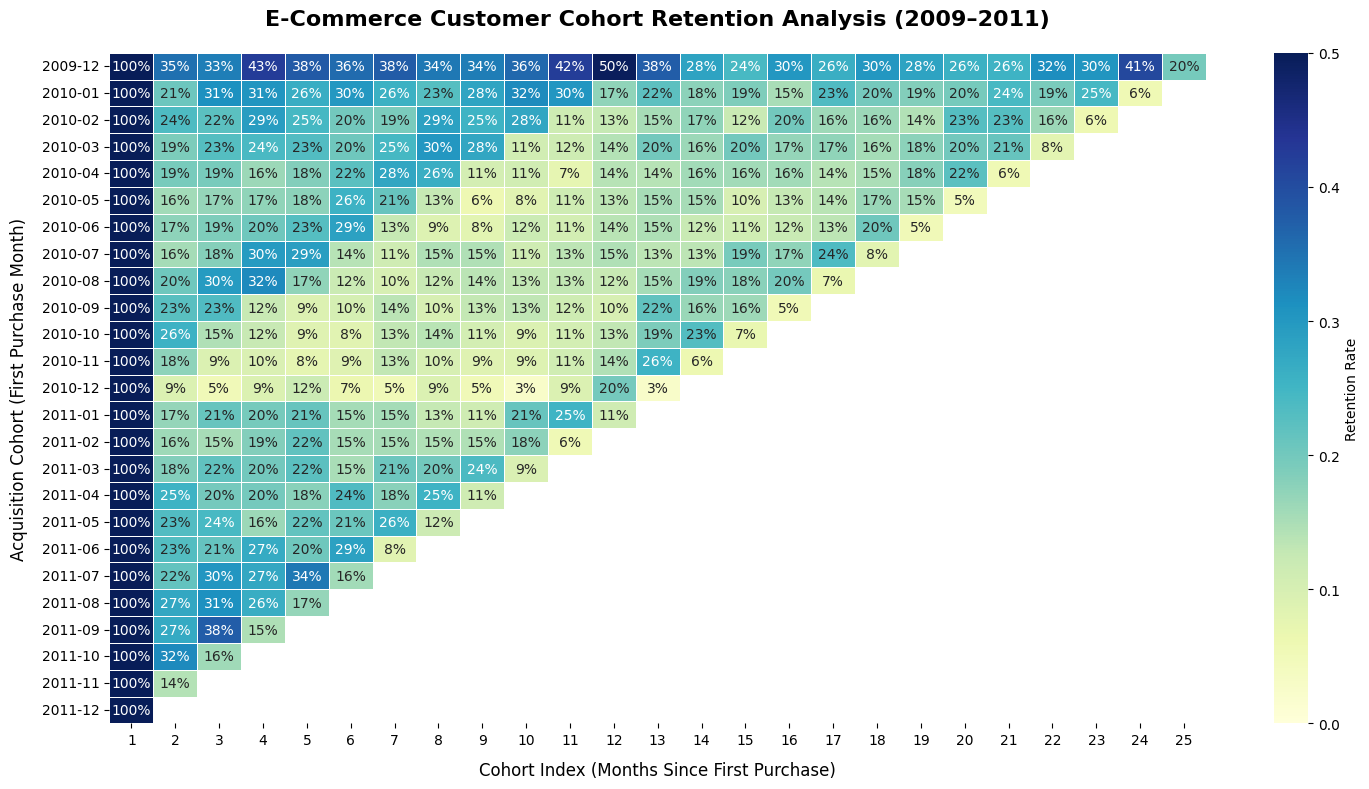

In [ ]:
# Set figure canvas
plt.figure(figsize=(15, 8))

# Generate heatmap visual
sns.heatmap(
    data = retention_matrix,
    annot = True,
    fmt = '.0%',               ## Format numbers as whole percentages (e.g., 35%)
    cmap = 'YlGnBu',    # Yellow to Green to Blue color ramp
    vmin = 0,
    vmax = 0.5,         # Anchors contrast so post-month 1 drops are visually distinct
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate'}
)
# Typography and visual structure
plt.title('E-Commerce Customer Cohort Retention Analysis (2009–2011)', fontsize=16, weight='bold', pad=20)
plt.xlabel('Cohort Index (Months Since First Purchase)', fontsize=12, labelpad=10)
plt.ylabel('Acquisition Cohort (First Purchase Month)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()